# Προσομοιώσεις Πλεγμάτων Επιταχυντών με Python και Xsuite
# Μάθημα 4ο: Tracking πολλών σωματιδίων σε δακτύλιο
#### Φυσική των Επιταχυντών
#### Μεταπτυχιακό Υποατομικής Φυσικής, 2o έτος
#### Τμήμα Φυσικής / Αριστοτέλειο Πανεπιστήμιο Θεσσαλονίκης
#### Εαρινό εξάμηνο 2025 

*T. Prebibaj, F. Antoniou, F. Asvesta, Y. Papaphilippou*

In [1]:
# Import custom tracking functions and useful libraries
from tracking_library import *
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

---
## 📌 Εγκάρσια δυναμική δέσμης σωματιδίων

- Μια δέσμη είναι ένα σύνολο από σωματίδια με διαφορετικές αρχικές συνθήκες (διαφορετικά $x$ και $x'$).  

- Σε έναν σταθερό δακτύλιο, κάθε σωματίδιο εκτελεί μια ταλάντωση βήτατρον με ένα συγκεκριμένο πλάτος, το οποίο εξαρτάται από τη συνάρτηση-βήτα και την single particle emittance. Όλα τα σωματίδια "βλέπουν" την ίδια συνάρτηση-βήτα κατά μήκος του δακτυλίου (είναι ιδιότητα του πλέγματος). Επίσης, η συχνότητα ταλάντωσης είναι η ίδια για όλα τα σωματίδια, δηλαδή έχουν την ίδια tune.  

- Η δυναμική της δέσμης είναι το αποτέλεσμα του superposition όλων αυτών των ταλαντώσεων.

### 📝 Άσκηση 15: δέσμη σωματιδίων κατά μήκος ενός δακτυλίου

Χρησιμοποιήστε το σύνολο σωματιδίων που ορίζεται παρακάτω παρακάτω (προς το παρόν αγνοήστε τις περίεργες τιμές).  

- Κάντε track όλα τα σωματίδια σε έναν δακτύλιο που αποτελείται από 16 FODO κελιά, με περίμετρο $160$ m και $f/L = 0.8$. Σχεδιάστε την τροχιά ενός σωματιδίου και το κέντρο μάζας (centroid) της δέσμης κατά μήκος της διάταξης.

- Σχεδιάστε την τυπική απόκλιση των $x$ συντεταγμένων (δηλ. το μέγεθος της δέσμης) κατά μήκος της διάταξης.  
  **Υπόδειξη:** Θυμηθείτε ότι στην έξοδο της `transportParticles`, το `'x'` περιέχει έναν πίνακα 2D με Ν γραμμές (δείκτης θέσης κατά μήκος του πλέγματος) και M στήλες (δείκτης σωματιδίου). Μπορείτε να υπολογίσετε την τυπική απόκλιση κάθε γραμμής με `np.std(N_times_M_array,1)`.

In [2]:
# Initializing the beam
N = 1500
X_0 = np.array([np.random.normal(0,1,N),
                np.random.normal(0,1,N)])
x0 = 0
xp0 = 0
sigx = np.sqrt(1e-6*8.24659992) 
sigxp = np.sqrt(1e-6/8.24659992)
X_0[0,:] = sigx*X_0[0,:]+x0
X_0[1,:] = sigxp*X_0[1,:]+xp0-(-1.28102523)/8.24659992*X_0[0,:]

In [3]:
# Modelling the ring
C = 160 # circumference in meters
Lcell = C/16 # length of one FODO cell in meters
L = Lcell/2 # length of one drift in the fodo cell
f = 0.8*L 
basic_cell = 5*D(L/10) + Q(f) + 10*D(L/10) + Q(-f) + 5*D(L/10)
myRing = basic_cell*16

# Track
transported_particles = transportParticles(X_0, myRing)

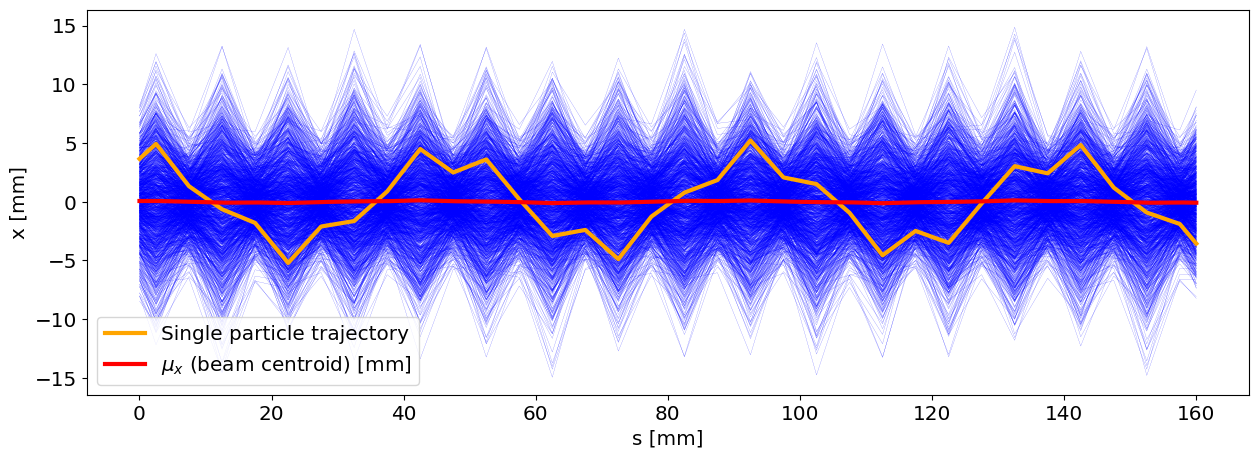

In [4]:
plt.plot(transported_particles['s'], transported_particles['x']*1e3, c='blue', linewidth=0.1)
plt.plot(transported_particles['s'], transported_particles['x'][:,0]*1e3, linewidth=3, color='orange', label='Single particle trajectory')
plt.plot(transported_particles['s'], np.mean(transported_particles['x']*1e3,1), c='red', linewidth=3, label=r'$\mu_{x}$ (beam centroid) [mm]')
plt.xlabel('s [mm]')
plt.ylabel('x [mm]')
plt.legend()

Text(0, 0.5, '$\\sigma_{x}$ (beam size) [mm$^2$]')

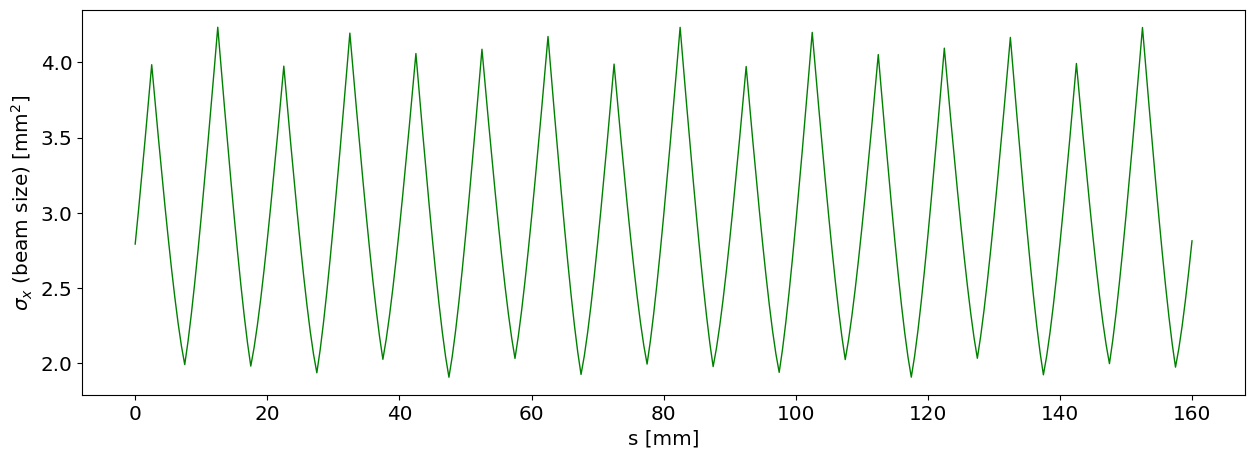

In [5]:
plt.plot(transported_particles['s'], np.std(transported_particles['x']*1e3,1), c='green', linewidth=1)
plt.xlabel('s [mm]')
plt.ylabel(r'$\sigma_{x}$ (beam size) [mm$^2$]')

> Παρατηρούμε ότι:  
> - Τα μεμονωμένα σωματίδια εκτελούν ταλαντώσεις βήτατρον.  
> - Κατά μέσο όρο, το κέντρο μάζας της δέσμης παραμένει στο μηδέν (κατά μέσο όρο η δέσμη είναι "στον άξονα").  
> - Το μέγεθος της δέσμης μεταβάλλεται σύμφωνα με τη διακύμανση της συνάρτησης-βήτα (βλ. Άσκηση 14).


### 📝 Άσκηση 16: δέσμη με αρχική μετατόπιση  

Επαναλάβετε την ίδια άσκηση όπως η προηγούμενη, αλλά τώρα με αρχική μετατόπιση της δέσμης κατά 2 mm στην κατεύθυνση $x$.

In [6]:
# Initializing the beam
X_new = np.array([X_0[0,:]+2e-3,
                  X_0[1,:]])

# Track
transported_particles = transportParticles(X_new, myRing)

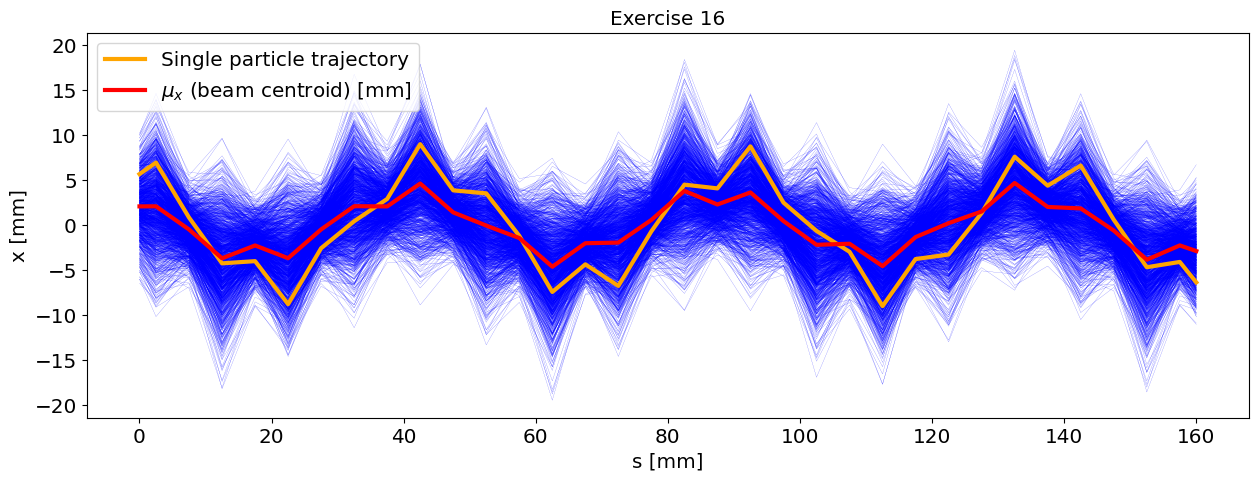

In [7]:
plt.plot(transported_particles['s'], transported_particles['x']*1e3, c='blue', linewidth=0.1)
plt.plot(transported_particles['s'], transported_particles['x'][:,0]*1e3, linewidth=3, color='orange', label='Single particle trajectory')
plt.plot(transported_particles['s'], np.mean(transported_particles['x']*1e3,1), c='red', linewidth=3, label=r'$\mu_{x}$ (beam centroid) [mm]')
plt.xlabel('s [mm]')
plt.ylabel('x [mm]')
plt.title('Exercise 16')
plt.legend()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2792669/1932906795.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_{x}$ (beam size) [mm$^2$]')


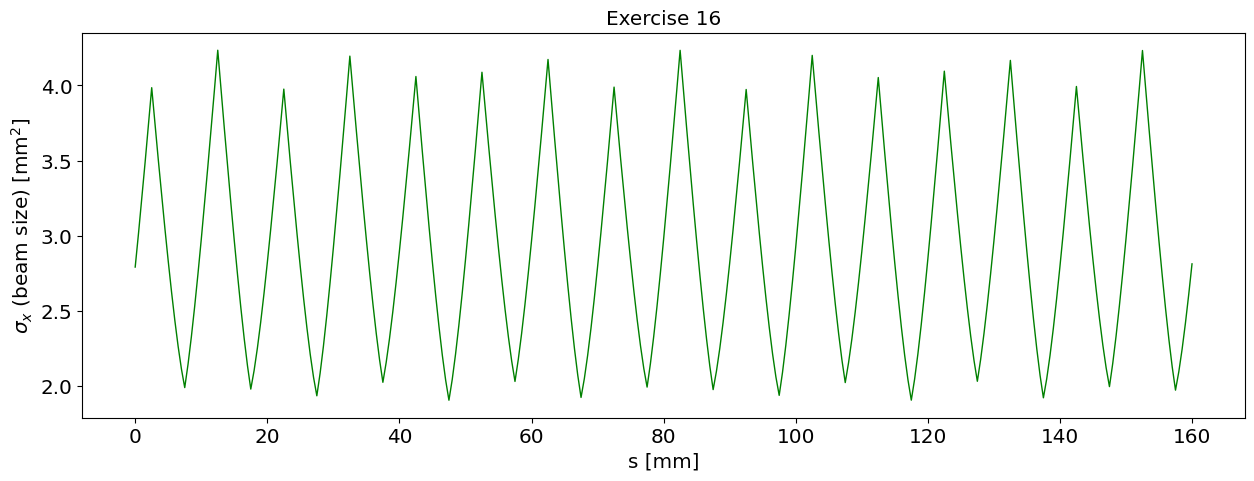

In [8]:
plt.plot(transported_particles['s'], np.std(transported_particles['x']*1e3,1), c='green', linewidth=1)
plt.xlabel('s [mm]')
plt.ylabel('$\sigma_{x}$ (beam size) [mm$^2$]')
plt.title('Exercise 16')
plt.show()

> Παρατηρούμε ότι:  
> - Όταν η δέσμη εισάγεται εκτός άξονα, το κέντρο μάζας της δέσμης επίσης εκτελεί ταλαντώσεις βήτατρον (injection misteering).  
> - Μπορεί να αποδειχθεί ότι η μέση θέση μιας δέσμης κατά μήκος της διάταξης είναι ίδια με την τροχιά ενός μεμονωμένου σωματιδίου που ξεκινά από το κέντρο της αρχικής κατανομής.  
> - Το μέγεθος της δέσμης δεν επηρεάζεται.

## Beam emittance

- One can easily demonstrate that the same matrix ($M$) used for tracking the coordinates ($(x_i, x'_i)$) of each single particle ($i$) from an initial point ($X_0$) to a final point ($X_s$) in a beamline:

    \begin{equation}
    X_s =  M\, X_0
    \end{equation}

  can also be used to track the **average trajectory** ($\langle X \rangle$) as well as the **covariance or sigma matrix** of the given particle coordinates distribution:

    \begin{equation}
    \langle X_s \rangle = 
    \left[
    \begin{array}{c}
    \langle x_i \rangle\\
    \langle x'_i \rangle
    \end{array}
    \right]_s 
    = M\, \langle X_0 \rangle
    \end{equation}

    \begin{equation}
    \Sigma_s := \left[
    \begin{array}{c}
    \langle x_i^2 \rangle \quad \langle x_i x'_i \rangle\\
    \langle x'_i x_i \rangle \quad \langle x_i^{'2} \rangle
    \end{array}
    \right]_s = \left[
    \begin{array}{c}
    \sigma_{x}^2\quad \sigma_{x}\sigma_{x'}\\
    \sigma_{x}\sigma_{x'}\quad \sigma_{x'}^2
    \end{array}
    \right]_s
    = M\, \Sigma_0\, M^T\, .
    \end{equation}

    We can therefore track the **average trajectory** and **covariance** of a beam simply starting from its initial average coordinates and covariance matrix in phase space.


- The sigma/covariance matrix is usually parametrized with the Twiss parameters as:

    \begin{equation}
    \left[
    \begin{array}{c}
    \sigma_{x}^2\quad \sigma_{x}\sigma_{x'}\\
    \sigma_{x}\sigma_{x'}\quad \sigma_{x'}^2
    \end{array}
    \right] =
        \epsilon
        \left[ 
        \begin{array}{cc}
            \beta   & -\alpha\\
            -\alpha & \gamma
        \end{array}
        \right] 
    \end{equation}

    where $\beta$, $\alpha$, $\gamma$ are the twiss parameters the certain s-position and that $\epsilon = \sqrt{\det(\Sigma)}$ is now the **beam emittance**. It is reminded that $\beta \gamma - \alpha^2 = 1$.

- We recall that $M$ is a real **symplectic** transformation, and its determinant is $\det(M) = +1$, therefore:

    \begin{equation}
    \epsilon_s^2 = \det(\Sigma_s) = \det( M\, \Sigma_0\, M^T ) = \det(M) \det(\Sigma_0) \det(M^T) = \det(\Sigma_0) = \epsilon_0^2
    \end{equation}

    which means that, like the single particle emittances, the beam emittance is also **preserved** along the ring.

### 📝 Άσκηση 17: διατήρηση της εκπεμπτικότητας δέσμης (beam emittance)

- Υπολογίστε τον πίνακα σίγμα (sigma matrix) του προηγούμενου παραδείγματος (σε όλα τα σημεία $s$ της διάταξης) και σχεδιάστε την emittance κατά μήκος του $s$.  

- Υπολογίστε τις παραμέτρους $\alpha$, $\beta$ και $\gamma$ από τον πίνακα σίγμα (παράμετροι Twiss). Σχεδιάστε τες και επαληθεύστε ότι $\beta\gamma - \alpha^2 = 1$.

In [9]:
sigmas = [] 
for i in range(len(transported_particles['s'])): # for every s-location of our lattice
    x_of_all_particles_at_s = transported_particles['x'][i,:]*1e3
    xp_of_all_particles_at_s = transported_particles['xp'][i,:]*1e3
    sigmas.append(np.cov(x_of_all_particles_at_s, xp_of_all_particles_at_s))
sigmas = np.array(sigmas)

# compute the emittance as sqrt of the determinant of all sigma matrices along 
# the beamline
emittance = np.sqrt(np.linalg.det(sigmas))
beamsize = np.sqrt(sigmas[:,0,0]) # is the same as np.std(transported_particles['x'],1)

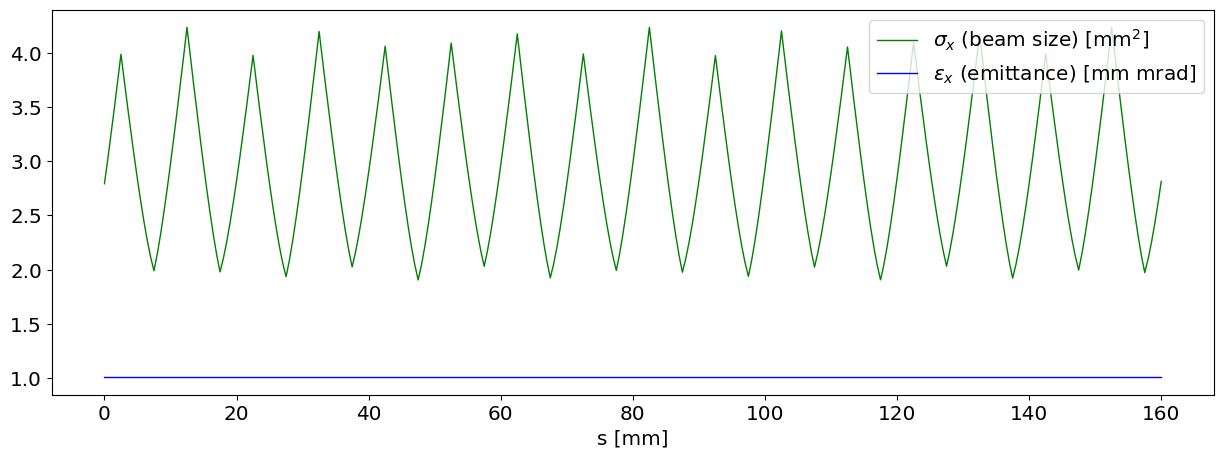

In [10]:
plt.plot(transported_particles['s'], beamsize, c='green', linewidth=1, label=r'$\sigma_{x}$ (beam size) [mm$^2$]')
plt.plot(transported_particles['s'], emittance, c='blue', linewidth=1, label=r'$\epsilon_x$ (emittance) [mm mrad]')
plt.xlabel('s [mm]')
plt.legend()

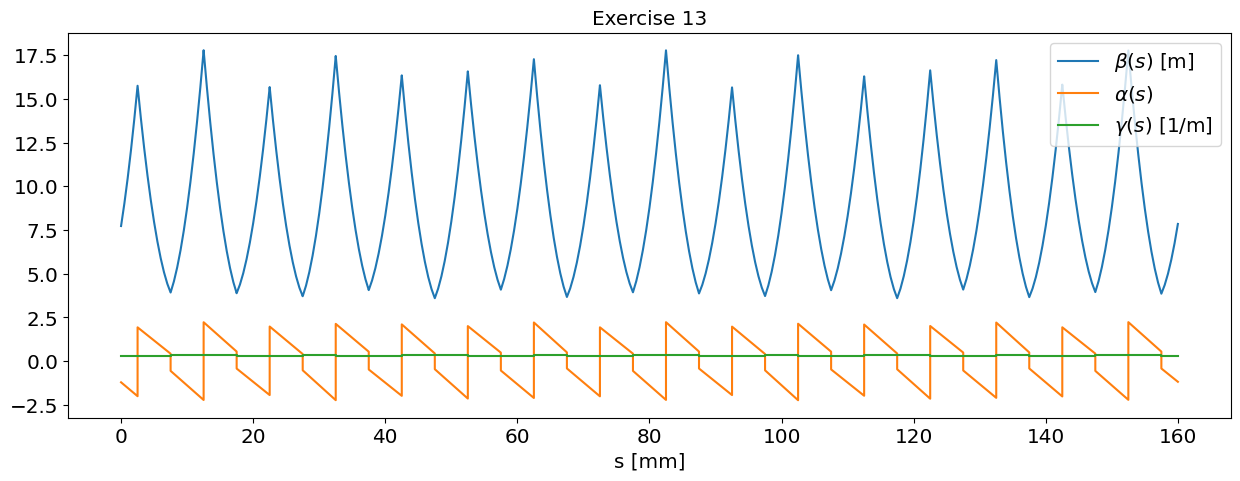

In [11]:
beta = beamsize**2/emittance
alpha = -sigmas[:,0,1]/emittance
gamma = sigmas[:,1,1]/emittance
plt.plot(transported_particles['s'], beta, label=r'$\beta(s)$ [m]')
plt.plot(transported_particles['s'], alpha, label=r'$\alpha(s)$')
plt.plot(transported_particles['s'], gamma, label=r'$\gamma(s)$ [1/m]')
plt.xlabel('s [mm]')
plt.legend()
plt.title('Exercise 13')
plt.show()

assert (beta*gamma - alpha**2).all()==1

> Σημείωση: Η συνάρτηση-βήτα επηρεάζει το μέγεθος της δέσμης, η συνάρτηση-άλφα την κλίση της, και η συνάρτηση-γάμα την απόκλιση. 
> Με την αλλαγή των ιδιοτήτων της διάταξής μας, δηλαδή τη θέση και ισχύ των τετραπόλων και το μήκος των διαστημάτων (drifts), οι παράμετροι Twiss αλλάζουν, όπως και το μέγεθος της δέσμης, το πλάτος και η συχνότητα των ταλαντώσεων. Η emittance όμως παραμένει αμετάβλητη.

### 📝 Άσκηση 18: emittance και εμβαδόν φασικού χώρου

- Στην κατανομή της Άσκησης 11, σχεδιάστε τον φασικό χώρο σε δύο διαφορετικές θέσεις $s$ της επιλογής σας (π.χ. $s=0$ και $s=15$ m). Τι παρατηρείτε;

  **Υπόδειξη:** Μπορείτε να χρησιμοποιήσετε τη βιβλιοθήκη `seaborn` για να οπτικοποιήσετε την 2D κατανομή, όπως στην Άσκηση 2.

- Επιλέξτε 3 σωματίδια (π.χ. τα πρώτα 3 του συνόλου σας) έτσι ώστε να ορίζουν ένα τρίγωνο εμβαδού $A$. Επαληθεύστε ότι το εμβαδόν αυτού του τριγώνου παραμένει το ίδιο μεταξύ των δύο σημείων $s$.

  **Υπόδειξη:** Το εμβαδόν ενός τριγώνου στον φασικό χώρο μπορεί να υπολογιστεί μέσω γραμμικής άλγεβρας. Μπορείτε να χρησιμοποιήσετε τη συνάρτηση `area` που δίνεται παρακάτω.

In [12]:
# this is the formula of the area of a triangle
from numpy.linalg import norm
def area(a, b, c) :
    '''a,b,c are the phase-space coordinates of three particles'''
    return 0.5 * norm( np.cross( b-a, c-a ) )

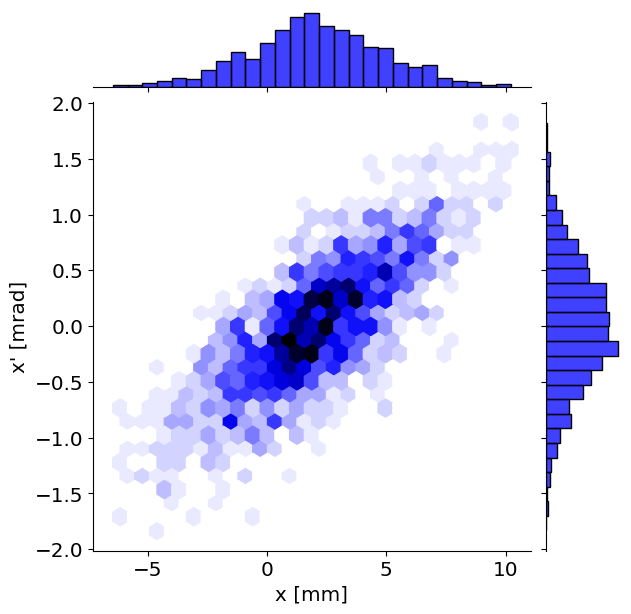

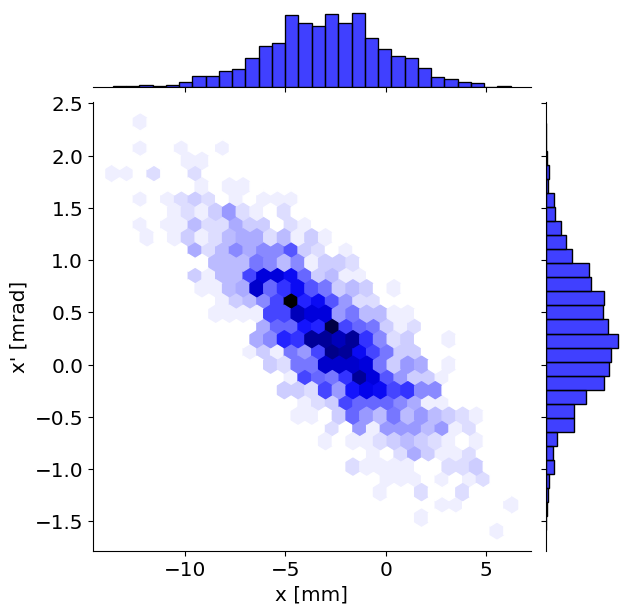

In [13]:
# particle distribution at s=0
X_0 = np.array([transported_particles['x'][0,:],
                transported_particles['xp'][0,:]])
g = sns.jointplot(x=X_0[0,:]*1e3, y=X_0[1,:]*1e3, kind="hex", color="b")
g.set_axis_labels("x [mm]", "x' [mrad]")

# particle distribution at s=15m
index = np.where(transported_particles['s']==15)[0][0]
X_1 = np.array([transported_particles['x'][index,:],
                transported_particles['xp'][index,:]])
g = sns.jointplot(x=X_1[0,:]*1e3, y=X_1[1,:]*1e3, kind="hex", color="b")
g.set_axis_labels("x [mm]", "x' [mrad]")

> Παρατηρούμε ότι:  
> - Τα σωματίδια σχηματίζουν ελλείψεις στον φασικό χώρο. Η έλλειψη στο $s=15$ m είναι περιστραμμένη.  
> - Ο προσανατολισμός των ελλείψεων αλλάζει κατά μήκος του $s$ και εξαρτάται από τις παραμέτρους Twiss.  

In [ ]:
# we take the first three particles in the beam (arbitrary choise)
print(f"Area enclosed of the three particles at s=s1: {area(X_0[:,0]*1e3,X_0[:,1]*1e3,X_0[:,2]*1e3)}")
print(f"Area enclosed of the three particles at s=s2: {area(X_1[:,0]*1e3,X_1[:,1]*1e3,X_1[:,2]*1e3)}")

In [ ]:
# Visualizing this:
plt.figure(figsize=(9,3))
#first triangle
plt.plot(X_0[:,:3][0]*1e3,X_0[:,:3][1]*1e3,'o-b')
plt.plot(X_0[:,[2,0]][0]*1e3,X_0[:,[2,0]][1]*1e3,'o-b', label='at s=0')
#second triangle
plt.plot(X_1[:,:3][0]*1e3,X_1[:,:3][1]*1e3,'o-r')
plt.plot(X_1[:,[2,0]][0]*1e3,X_1[:,[2,0]][1]*1e3,'o-r',label='at s=15m')
plt.legend()
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.grid(True)

> Σημείωση: Το εμβαδόν του φασικού χώρου διατηρείται. Η emittance της δέσμης ισούται με το εμβαδόν του φασικού χώρου που καταλαμβάνει η δέσμη διαιρεμένο με $2\pi$.